# Problem 2 — Mapping airports with multidimensional scaling

We are given the great-circle distances (in km) between six northern-hemisphere airports:

|       | CPH   | EWR   | KEF  | LHR  | NRT  |
|-------|------:|------:|-----:|-----:|-----:|
| **EWR** | 6223 |       |      |      |      |
| **KEF** | 2151 | 4185  |      |      |      |
| **LHR** |  981 | 5577  | 1900 |      |      |
| **NRT** | 8734 | 10833 | 8844 | 9614 |      |
| **YVR** | 7685 | 3908  | 5702 | 7601 | 7521 |

*Key:* CPH = Copenhagen, EWR = Newark, KEF = Keflavík, LHR = London Heathrow, NRT = Tokyo Narita, YVR = Vancouver.

The task is to **draw a map** (an embedding in $\mathbb{R}^2$) that reproduces these distances as faithfully as possible in relative terms. This is exactly the problem solved by **multidimensional scaling (MDS)** (Week 4): given only a matrix of pairwise dissimilarities, MDS places points $z_1,\dots,z_n$ in $\mathbb{R}^q$ so that the embedded Euclidean distances $\lVert z_i-z_j\rVert$ match the given distances $d_{ij}$. We use the **least-squares scaling (stress)** objective from the Week 4 slides,
$$S_M(z_1,\dots,z_n)=\sum_{i\neq j}\bigl(d_{ij}-\lVert z_i-z_j\rVert\bigr)^2,$$
minimised by `sklearn.manifold.MDS` with `dissimilarity="precomputed"`, following the Week 4 reference solution.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import MDS
from sklearn.metrics import pairwise_distances

plt.style.use("ggplot")
# sklearn 1.8 deprecates `dissimilarity` (-> `metric`); silence the migration notices.
warnings.filterwarnings("ignore", category=FutureWarning)

labels = ["CPH", "EWR", "KEF", "LHR", "NRT", "YVR"]

# Lower triangle of the table (km), rows EWR, KEF, LHR, NRT, YVR against CPH, EWR, KEF, LHR, NRT.
lower = [
    [6223],
    [2151, 4185],
    [981, 5577, 1900],
    [8734, 10833, 8844, 9614],
    [7685, 3908, 5702, 7601, 7521],
]

n = len(labels)
D = np.zeros((n, n))
for i, row in enumerate(lower, start=1):
    for j, d in enumerate(row):
        D[i, j] = D[j, i] = d  # symmetric, zero diagonal

pd.DataFrame(D, index=labels, columns=labels)

,CPH,EWR,KEF,LHR,NRT,YVR
CPH,0.0,6223.0,2151.0,981.0,8734.0,7685.0
EWR,6223.0,0.0,4185.0,5577.0,10833.0,3908.0
KEF,2151.0,4185.0,0.0,1900.0,8844.0,5702.0
LHR,981.0,5577.0,1900.0,0.0,9614.0,7601.0
NRT,8734.0,10833.0,8844.0,9614.0,0.0,7521.0
YVR,7685.0,3908.0,5702.0,7601.0,7521.0,0.0


## Part (a) — the map in $\mathbb{R}^2$

We embed the precomputed distance matrix into $\mathbb{R}^2$ by minimising the stress $S_M$. The orientation of the result is arbitrary: stress is invariant under rotation, reflection and translation, so MDS fixes only the *relative* positions of the airports.

The stress objective is non-convex, so the SMACOF optimiser inside `MDS` can converge to a poor local minimum from a single random start. We therefore use many random restarts (`n_init=300`) and a tight convergence tolerance and keep the best (lowest-stress) configuration.

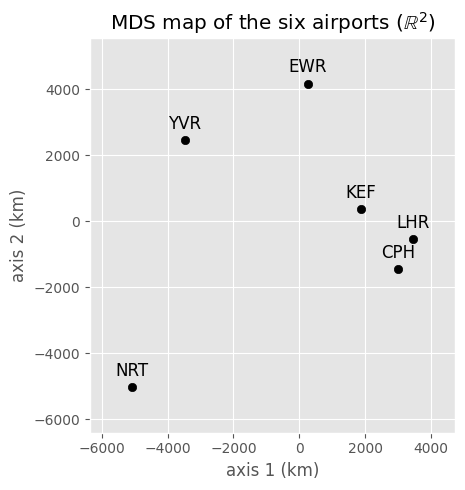

In [2]:
mds2 = MDS(
    n_components=2,
    dissimilarity="precomputed",
    random_state=1234,
    normalized_stress=False,
    init="random",
    n_init=300,
    max_iter=1000,
    eps=1e-10,
)
Z = mds2.fit_transform(D)

plt.figure(figsize=(6, 5))
plt.scatter(Z[:, 0], Z[:, 1], color="black", zorder=3)
for (x, y), name in zip(Z, labels):
    plt.annotate(name, (x, y), textcoords="offset points", xytext=(0, 8),
                 ha="center", fontsize=12)
plt.gca().set_aspect("equal")
plt.margins(0.15)
plt.xlabel("axis 1 (km)")
plt.ylabel("axis 2 (km)")
plt.title(r"MDS map of the six airports ($\mathbb{R}^2$)")
plt.tight_layout()
plt.show()

The relative layout matches real geography (up to an arbitrary rotation/reflection): the European/North-Atlantic group CPH–KEF–LHR sits together with KEF (Iceland) out towards the Atlantic, EWR (Newark) lies across the Atlantic from them, YVR (Vancouver) is off on the Pacific side of North America, and NRT (Tokyo) is the most isolated point, far from the Atlantic cluster.

## Part (b) — how accurate is the map, and why can it not be perfect?

Accuracy is measured by the stress $S_M$ itself. Because raw stress is in km$^2$ and scale-dependent, we also report the dimensionless **Kruskal stress-1**,
$$\text{stress-1}=\sqrt{\frac{S_M}{\sum_{i<j} d_{ij}^2}},$$
and draw a **Shepard diagram** comparing the map distances against the true great-circle distances.

Raw stress  S_M     = 1.5086e+05 km^2
Kruskal stress-1    = 0.0149  (1.49%)
Largest pairwise error = 194 km


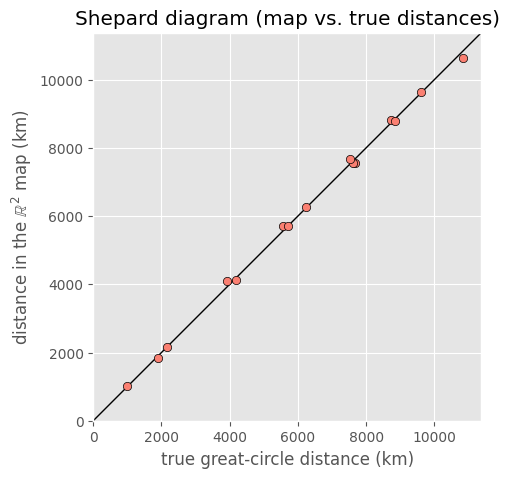

In [3]:
iu = np.triu_indices(n, k=1)
d_true = D[iu]
d_map = pairwise_distances(Z)[iu]

stress = mds2.stress_                      # S_M minimised by MDS
kruskal = np.sqrt(stress / np.sum(d_true ** 2))
max_err = np.max(np.abs(d_true - d_map))

print("Raw stress  S_M     = %.4e km^2" % stress)
print("Kruskal stress-1    = %.4f  (%.2f%%)" % (kruskal, 100 * kruskal))
print("Largest pairwise error = %.0f km" % max_err)

lim = max(d_true.max(), d_map.max()) * 1.05
plt.figure(figsize=(5, 5))
plt.plot([0, lim], [0, lim], color="black", lw=1, zorder=1)
plt.scatter(d_true, d_map, color="salmon", edgecolor="k", zorder=2)
plt.gca().set_aspect("equal")
plt.xlim(0, lim)
plt.ylim(0, lim)
plt.xlabel("true great-circle distance (km)")
plt.ylabel(r"distance in the $\mathbb{R}^2$ map (km)")
plt.title("Shepard diagram (map vs. true distances)")
plt.tight_layout()
plt.show()

**The map is very accurate in relative terms but not exact.** The points lie almost on the diagonal of the Shepard diagram and the Kruskal stress-1 is only about $1.5\%$, with the largest single pairwise error a couple of hundred km against distances of up to ~10 800 km — a relative error of a few percent at most.

It **cannot be perfectly accurate** because the table records **great-circle distances**, i.e. *geodesic* distances measured along the curved surface of the Earth, which is (approximately) a sphere $\mathbb{S}^2$. The map asks for *Euclidean* (straight-line) distances in the flat plane $\mathbb{R}^2$. As the Week 4 slides on non-linear dimensionality reduction illustrate ($\mathbb{S}^2\to\mathbb{R}^2$), a curved 2-manifold cannot be flattened into the plane without distorting distances — the same reason every flat world map distorts the globe. MDS finds the best flat Euclidean proxy for these curved distances, but a non-zero stress necessarily remains.

## Part (c) — does embedding in $\mathbb{R}^d$ for $d>2$ help?

We repeat MDS for $d=1,\dots,5$ (with $n=6$ points there are at most $n-1=5$ useful dimensions) using identical settings, and plot the minimised stress against $d$.

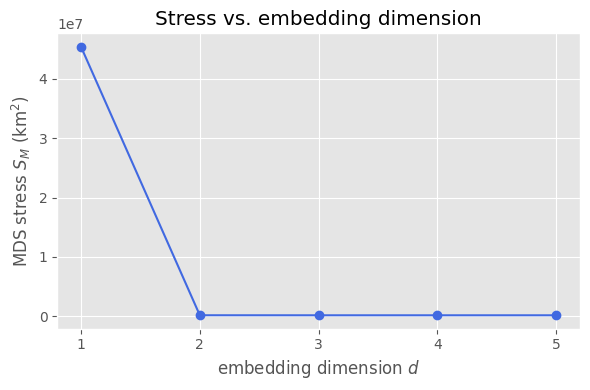

d = 1 :  stress = 4.5427e+07
d = 2 :  stress = 1.5086e+05
d = 3 :  stress = 1.4506e+05
d = 4 :  stress = 1.4506e+05
d = 5 :  stress = 1.4506e+05


In [4]:
dims = list(range(1, 6))
stresses = []
for d in dims:
    mds_d = MDS(
        n_components=d,
        dissimilarity="precomputed",
        random_state=1234,
        normalized_stress=False,
        init="random",
        n_init=300,
        max_iter=1000,
        eps=1e-10,
    )
    mds_d.fit_transform(D)
    stresses.append(mds_d.stress_)

plt.figure(figsize=(6, 4))
plt.plot(dims, stresses, "-o", color="royalblue", zorder=3)
plt.xticks(dims)
plt.xlabel("embedding dimension $d$")
plt.ylabel(r"MDS stress $S_M$ (km$^2$)")
plt.title("Stress vs. embedding dimension")
plt.tight_layout()
plt.show()

for d, s in zip(dims, stresses):
    print("d = %d :  stress = %.4e" % (d, s))

## Conclusion (Part (c))

**Increasing the dimensionality helps, but only up to a point, and never makes the map exact.** Each extra dimension gives MDS more freedom to satisfy the distance constraints, so the minimum stress can only decrease (or stay equal) as $d$ grows. The curve shows a large drop from $d=1$ to $d=2$, a further small improvement at $d=3$, and then a **plateau**: $d=4$ and $d=5$ give essentially the same stress as $d=3$. This makes sense — the airports lie on the (2-sphere) surface of the Earth, so three Euclidean dimensions already capture essentially all of the embeddable structure.

Crucially, the stress **does not reach zero even at $d=5$**. Great-circle (geodesic) distances on a sphere are not Euclidean distances in *any* dimension, so no finite-dimensional Euclidean embedding can reproduce them exactly; a non-zero irreducible stress always remains. In practice the gain beyond $\mathbb{R}^2$ is small here, so the 2-D map of part (a) is already a faithful relative representation — which is also why a flat map, rather than a higher-dimensional one, is the useful answer to the original question.